# 04: Network Analysis

Data: Atlas HS92
Period: 2017, 2019, 2021, 2022, 2023
N: 50 countries, ~1600 edges

In [ ]:
# ============================================================
# NOTEBOOK 4 — ANALYSE RESEAU COMMERCIAL
# Centralite  ·  Communautes  ·  Reorientation geopolitique
# ============================================================
#
# QUESTION CENTRALE :
#   La Russie a-t-elle migre du "bloc commercial europeen"
#   vers le "bloc asiatique" ?  Cette migration est-elle
#   visible dans la topologie du reseau commercial mondial ?
#
# APPROCHE METHODOLOGIQUE :
#   1. Construction du reseau commercial mondial (top 50 pays)
#   2. Mesures de centralite : degree, betweenness, eigenvector
#   3. Detection de communautes (Louvain) : 2017 vs 2023
#   4. Reorientation par region (Europe -> Asie)
#   5. Visualisation reseau
#
# DONNEES :
#   - Harvard Atlas HS92 (bilateral annuel, 1992-2024)
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from pathlib import Path
import warnings, gc

warnings.filterwarnings("ignore", category=FutureWarning)

import networkx as nx
try:
    import community as community_louvain
    _HAS_LOUVAIN = True
    print("python-louvain : OK")
except ImportError:
    _HAS_LOUVAIN = False
    print("python-louvain non installe — pip install python-louvain")

plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams.update({
    "figure.figsize": (12, 5),
    "font.size": 11,
    "axes.titlesize": 13,
    "axes.labelsize": 12,
    "figure.dpi": 80,
    "savefig.bbox": "tight",
    "savefig.dpi": 120,
})

# --- Chemins ---
_candidates = [Path.cwd(), Path.cwd().parent]
for c in _candidates:
    _proj = c / "russia_china_dependency"
    if _proj.exists() and (_proj / "01_raw_data").exists():
        PROJECT_ROOT = c
        break
else:
    PROJECT_ROOT = Path.cwd()

PROJECT = PROJECT_ROOT / "russia_china_dependency"
RAW     = PROJECT / "01_raw_data"
PROCESSED = PROJECT / "02_processed_data"
FIGURES = PROJECT_ROOT / "reports" / "figures"
FIGURES.mkdir(parents=True, exist_ok=True)

# Classification regionale simplifiee
REGIONS = {
    # Europe (UE-27 + UK + Suisse + Norvege)
    "DEU": "Europe", "FRA": "Europe", "ITA": "Europe", "NLD": "Europe",
    "ESP": "Europe", "POL": "Europe", "BEL": "Europe", "SWE": "Europe",
    "AUT": "Europe", "IRL": "Europe", "CZE": "Europe", "DNK": "Europe",
    "FIN": "Europe", "PRT": "Europe", "ROU": "Europe", "GRC": "Europe",
    "HUN": "Europe", "SVK": "Europe", "BGR": "Europe", "HRV": "Europe",
    "LTU": "Europe", "SVN": "Europe", "LVA": "Europe", "EST": "Europe",
    "LUX": "Europe", "CYP": "Europe", "MLT": "Europe",
    "GBR": "Europe", "CHE": "Europe", "NOR": "Europe",
    # Asie
    "CHN": "Asie", "JPN": "Asie", "KOR": "Asie", "IND": "Asie",
    "IDN": "Asie", "THA": "Asie", "VNM": "Asie", "MYS": "Asie",
    "SGP": "Asie", "PHL": "Asie", "BGD": "Asie", "PAK": "Asie",
    "TWN": "Asie", "HKG": "Asie", "MMR": "Asie", "KHM": "Asie",
    "LKA": "Asie",
    # CEI / Post-sovietique
    "RUS": "CEI", "KAZ": "CEI", "UKR": "CEI", "BLR": "CEI",
    "UZB": "CEI", "AZE": "CEI", "GEO": "CEI", "TKM": "CEI",
    "ARM": "CEI",
    # Moyen-Orient
    "TUR": "Moyen-Orient", "SAU": "Moyen-Orient", "ARE": "Moyen-Orient",
    "ISR": "Moyen-Orient", "IRN": "Moyen-Orient", "IRQ": "Moyen-Orient",
    "QAT": "Moyen-Orient", "KWT": "Moyen-Orient", "OMN": "Moyen-Orient",
    "EGY": "Moyen-Orient",
    # Ameriques
    "USA": "Ameriques", "CAN": "Ameriques", "MEX": "Ameriques",
    "BRA": "Ameriques", "ARG": "Ameriques", "CHL": "Ameriques",
    "COL": "Ameriques", "PER": "Ameriques",
    # Afrique
    "ZAF": "Afrique", "NGA": "Afrique", "AGO": "Afrique",
    "DZA": "Afrique", "MAR": "Afrique", "KEN": "Afrique",
    "TUN": "Afrique", "GHA": "Afrique", "TZA": "Afrique",
    # Oceanie
    "AUS": "Oceanie", "NZL": "Oceanie",
}

REGION_COLORS = {
    "Europe": "#1f77b4",
    "Asie": "#d62728",
    "Ameriques": "#2ca02c",
    "Moyen-Orient": "#ff7f0e",
    "CEI": "#9467bd",
    "Afrique": "#8c564b",
    "Oceanie": "#17becf",
    "Autre": "gray",
}

print(f"Setup OK | Root: {PROJECT_ROOT}")
print(f"Figures  -> {FIGURES}")


python-louvain : OK
Setup OK | Racine : d:\Users\Proprietaire\Desktop\Projet_perso\Chine-russie
Figures  -> d:\Users\Proprietaire\Desktop\Projet_perso\Chine-russie\reports\figures


In [ ]:
# ============================================================
# 1. Load & build networks
# ============================================================

atlas = pd.read_csv(
    RAW / "complexity" / "trade_hs92" / "hs92_country_country_year.csv"
)
print(f"Atlas HS92 : {len(atlas):,} paires, annees {atlas['year'].min()}-{atlas['year'].max()}")

# Annees d'interet pour la comparaison
YEARS = sorted(atlas["year"].unique())
FOCUS_YEARS = [y for y in [2017, 2019, 2021, 2022, 2023] if y in YEARS]
print(f"Annees focus : {FOCUS_YEARS}")

def build_network(atlas_df, year, top_n=50, min_edge_bn=0.5):
    """
    Construit un graphe dirige pondere a partir des donnees Atlas.
    
    Parameters
    ----------
    year     : annee a filtrer
    top_n    : nombre de pays a garder (par volume total)
    min_edge_bn : seuil minimum pour une arete (en milliards USD)
    
    Returns
    -------
    G : nx.DiGraph
    """
    df = atlas_df[atlas_df["year"] == year].copy()
    
    # Identifier les top_n pays par volume total d'echanges
    totals = (
        df.groupby("country_iso3_code")[["export_value", "import_value"]].sum()
        .sum(axis=1).sort_values(ascending=False)
    )
    top_countries = totals.head(top_n).index.tolist()
    
    # Filtrer aux top pays
    df = df[
        df["country_iso3_code"].isin(top_countries) &
        df["partner_iso3_code"].isin(top_countries)
    ].copy()
    
    # Construire le graphe
    G = nx.DiGraph()
    for iso in top_countries:
        region = REGIONS.get(iso, "Autre")
        G.add_node(iso, region=region, color=REGION_COLORS.get(region, "gray"))
    
    for _, row in df.iterrows():
        exp_bn = row["export_value"] / 1e9
        if exp_bn >= min_edge_bn:
            G.add_edge(row["country_iso3_code"], row["partner_iso3_code"],
                       weight=exp_bn)
    
    return G

# Construire les reseaux
networks = {}
for y in FOCUS_YEARS:
    G = build_network(atlas, y, top_n=50, min_edge_bn=0.5)
    networks[y] = G
    n_nodes = G.number_of_nodes()
    n_edges = G.number_of_edges()
    total_w = sum(d["weight"] for _, _, d in G.edges(data=True))
    print(f"  {y} : {n_nodes} pays, {n_edges} liens, {total_w:,.0f} Mrd USD")

print(f"\nReseaux construits pour {len(networks)} annees.")


Atlas HS92 : 974,282 paires, annees 1988-2024
Annees focus : [2017, 2019, 2021, 2022, 2023]
  2017 : 50 pays, 1557 liens, 13,536 Mrd USD
  2019 : 50 pays, 1588 liens, 14,446 Mrd USD
  2021 : 50 pays, 1673 liens, 17,116 Mrd USD
  2022 : 50 pays, 1711 liens, 18,965 Mrd USD
  2023 : 50 pays, 1672 liens, 18,110 Mrd USD

Reseaux construits pour 5 annees.


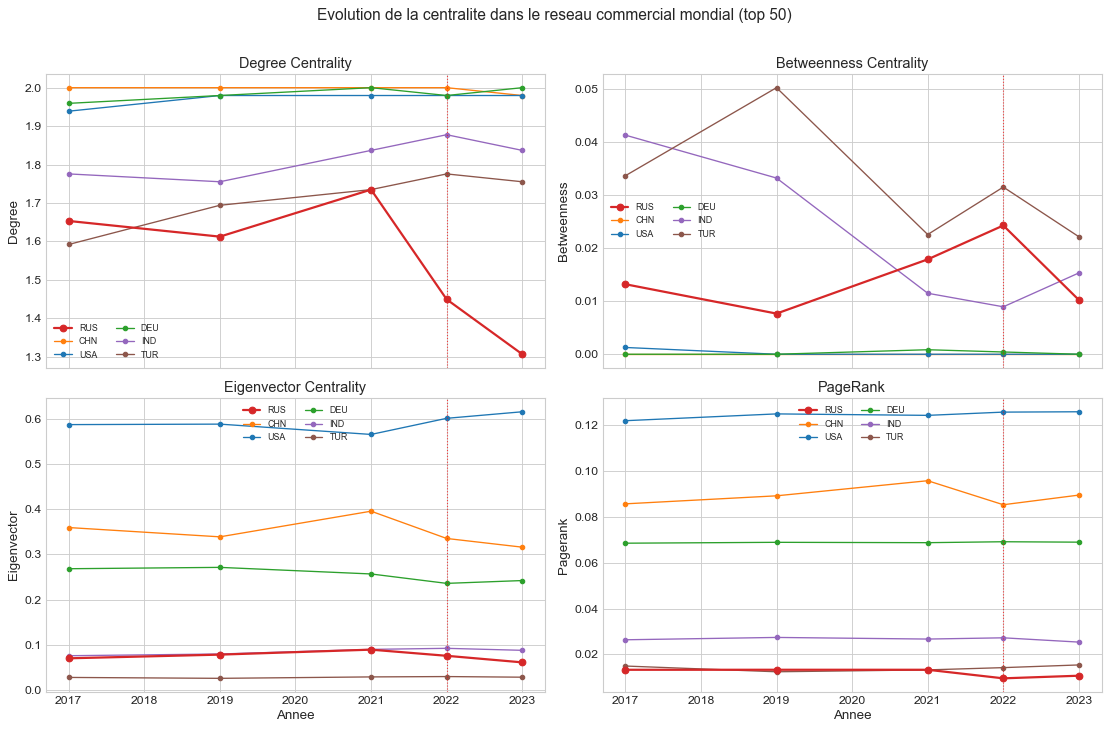

CENTRALITE — Comparaison 2017 vs 2023

  RUS:
    degree          : 1.6531 -> 1.3061  (-21.0%)
    betweenness     : 0.0132 -> 0.0102  (-22.6%)
    eigenvector     : 0.0700 -> 0.0610  (-12.8%)
    pagerank        : 0.0133 -> 0.0107  (-19.4%)

  CHN:
    degree          : 2.0000 -> 1.9796  (-1.0%)
    betweenness     : 0.0000 -> 0.0000  (+nan%)
    eigenvector     : 0.3593 -> 0.3158  (-12.1%)
    pagerank        : 0.0857 -> 0.0896  (+4.5%)

  USA:
    degree          : 1.9388 -> 1.9796  (+2.1%)
    betweenness     : 0.0013 -> 0.0000  (-100.0%)
    eigenvector     : 0.5869 -> 0.6153  (+4.8%)
    pagerank        : 0.1220 -> 0.1259  (+3.2%)

  DEU:
    degree          : 1.9592 -> 2.0000  (+2.1%)
    betweenness     : 0.0000 -> 0.0000  (+nan%)
    eigenvector     : 0.2682 -> 0.2420  (-9.8%)
    pagerank        : 0.0686 -> 0.0690  (+0.7%)

  IND:
    degree          : 1.7755 -> 1.8367  (+3.4%)
    betweenness     : 0.0412 -> 0.0153  (-62.9%)
    eigenvector     : 0.0758 -> 0.0877  (+15.7%)
 

In [5]:
# ============================================================
# 2. ANALYSE DE CENTRALITE
# ============================================================
#
# Mesures :
#   - Degree centrality (in + out) : combien de partenaires ?
#   - Betweenness : la Russie est-elle un "pont" entre regions ?
#   - Eigenvector : est-elle connectee a des pays importants ?
#   - PageRank : importance ponderee dans le reseau
# ============================================================

TRACK_COUNTRIES = ["RUS", "CHN", "USA", "DEU", "IND", "TUR"]

centrality_data = []
for y in FOCUS_YEARS:
    G = networks[y]
    
    # Convertir en non-dirige pour certaines mesures
    G_und = G.to_undirected()
    
    dc    = nx.degree_centrality(G)
    bc    = nx.betweenness_centrality(G, weight="weight", normalized=True)
    pr    = nx.pagerank(G, weight="weight")
    
    # Eigenvector sur le graphe non-dirige (plus stable)
    try:
        ec = nx.eigenvector_centrality(G_und, weight="weight", max_iter=1000)
    except nx.PowerIterationFailedConvergence:
        ec = {n: 0 for n in G.nodes}
    
    for iso in TRACK_COUNTRIES:
        if iso in G.nodes:
            centrality_data.append({
                "year": y, "country": iso,
                "degree": dc.get(iso, 0),
                "betweenness": bc.get(iso, 0),
                "eigenvector": ec.get(iso, 0),
                "pagerank": pr.get(iso, 0),
            })

cent_df = pd.DataFrame(centrality_data)

# --- Visualisation ---
fig, axes = plt.subplots(2, 2, figsize=(14, 9), sharex=True)
metrics = ["degree", "betweenness", "eigenvector", "pagerank"]
titles  = ["Degree Centrality", "Betweenness Centrality",
           "Eigenvector Centrality", "PageRank"]

country_colors = {
    "RUS": "#d62728", "CHN": "#ff7f0e", "USA": "#1f77b4",
    "DEU": "#2ca02c", "IND": "#9467bd", "TUR": "#8c564b",
}

for ax, metric, title in zip(axes.flat, metrics, titles):
    for iso in TRACK_COUNTRIES:
        sub = cent_df[cent_df["country"] == iso]
        if len(sub) == 0:
            continue
        ax.plot(sub["year"], sub[metric], "o-",
                color=country_colors.get(iso, "gray"),
                lw=2 if iso == "RUS" else 1.2,
                ms=6 if iso == "RUS" else 4,
                label=iso, zorder=5 if iso == "RUS" else 2)
    ax.axvline(2022, color="red", ls=":", lw=1, alpha=0.7)
    ax.set_title(title)
    ax.legend(fontsize=8, ncol=2)
    ax.set_ylabel(metric.capitalize())

axes[1, 0].set_xlabel("Annee")
axes[1, 1].set_xlabel("Annee")
fig.suptitle("Evolution de la centralite dans le reseau commercial mondial (top 50)",
             fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig(FIGURES / "nb4_centrality_evolution.png", dpi=120, bbox_inches="tight")
plt.show(); plt.close("all"); gc.collect()

# --- Tableau recapitulatif ---
print("=" * 72)
print("CENTRALITE — Comparaison 2017 vs 2023")
print("=" * 72)
for iso in TRACK_COUNTRIES:
    for metric in metrics:
        v17 = cent_df.loc[(cent_df["country"]==iso) & (cent_df["year"]==FOCUS_YEARS[0]), metric]
        v23 = cent_df.loc[(cent_df["country"]==iso) & (cent_df["year"]==FOCUS_YEARS[-1]), metric]
        if len(v17) > 0 and len(v23) > 0:
            v17, v23 = v17.values[0], v23.values[0]
            chg = ((v23 / v17) - 1) * 100 if v17 > 0 else float("nan")
            if metric == metrics[0]:
                print(f"\n  {iso}:")
            print(f"    {metric:15s} : {v17:.4f} -> {v23:.4f}  ({chg:+.1f}%)")


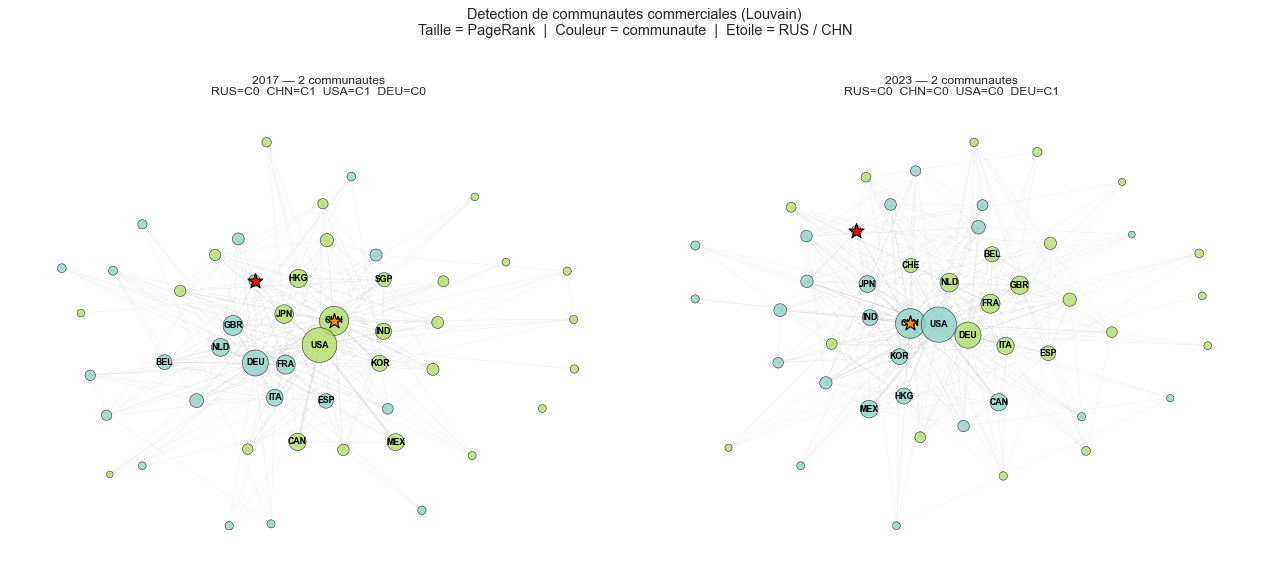

MIGRATION DE COMMUNAUTE — Russie

  2017 : Russie dans communaute C0
    Membres (22) : AUT, BEL, CHE, CZE, DEU, DNK, ESP, FIN, FRA, GBR, HUN, IRL, ITA, NLD, NOR, POL, PRT, ROU, RUS, SVK, SWE, TUR
    Composition regionale :
      Europe          : 20 pays
      CEI             : 1 pays
      Moyen-Orient    : 1 pays

  2023 : Russie dans communaute C0
    Membres (26) : ARE, ARG, AUS, BRA, CAN, CHL, CHN, HKG, IDN, IND, IRQ, ISR, JPN, KOR, MEX, MYS, PHL, QAT, RUS, SAU, SGP, THA, TWN, USA, VNM, ZAF
    Composition regionale :
      Asie            : 12 pays
      Ameriques       : 6 pays
      Moyen-Orient    : 5 pays
      Oceanie         : 1 pays
      CEI             : 1 pays
      Afrique         : 1 pays

  2017 : RUS et CHN dans la meme communaute ? NON

  2023 : RUS et CHN dans la meme communaute ? OUI


In [6]:
# ============================================================
# 3. DETECTION DE COMMUNAUTES  (Louvain)
# ============================================================
#
# L'algorithme de Louvain detecte des "blocs" de pays qui
# commercent intensement entre eux.
#
# Hypothese : en 2017, la Russie est dans le "bloc europeen".
#             en 2023, elle a migre vers le "bloc asiatique".
# ============================================================

if not _HAS_LOUVAIN:
    print("python-louvain non disponible. Installer avec : pip install python-louvain")
else:
    compare_years = [FOCUS_YEARS[0], FOCUS_YEARS[-1]]  # premier et dernier
    
    fig, axes = plt.subplots(1, 2, figsize=(16, 7))
    community_results = {}
    
    for ax, year in zip(axes, compare_years):
        G = networks[year]
        G_und = G.to_undirected()
        
        # Ponderer par le log du commerce pour eviter que les mega-flux dominent
        for u, v, d in G_und.edges(data=True):
            d["log_weight"] = np.log1p(d.get("weight", 1))
        
        # Detection Louvain
        partition = community_louvain.best_partition(G_und, weight="log_weight",
                                                     random_state=42)
        community_results[year] = partition
        
        n_communities = len(set(partition.values()))
        
        # Identifier la communaute de la Russie
        rus_comm = partition.get("RUS", -1)
        chn_comm = partition.get("CHN", -1)
        usa_comm = partition.get("USA", -1)
        deu_comm = partition.get("DEU", -1)
        
        # Couleurs par communaute
        comm_colors_palette = plt.cm.Set3(np.linspace(0, 1, max(n_communities, 3)))
        node_colors = [comm_colors_palette[partition.get(n, 0)] for n in G_und.nodes]
        
        # Layout
        pos = nx.spring_layout(G_und, weight="log_weight", seed=42, k=2.5)
        
        # Taille des noeuds = PageRank
        pr = nx.pagerank(G, weight="weight")
        node_sizes = [pr.get(n, 0.01) * 8000 for n in G_und.nodes]
        
        # Dessiner
        nx.draw_networkx_nodes(G_und, pos, ax=ax, node_color=node_colors,
                               node_size=node_sizes, alpha=0.8, edgecolors="black", linewidths=0.5)
        
        # Aretes (seulement les plus importantes pour lisibilite)
        edges = [(u, v) for u, v, d in G_und.edges(data=True) if d.get("weight", 0) > 5]
        if edges:
            edge_weights = [G_und[u][v].get("weight", 1) for u, v in edges]
            max_w = max(edge_weights) if edge_weights else 1
            edge_widths = [0.3 + 2.0 * w / max_w for w in edge_weights]
            nx.draw_networkx_edges(G_und, pos, ax=ax, edgelist=edges,
                                  width=edge_widths, alpha=0.15, edge_color="gray")
        
        # Labels pour les pays importants
        important = [n for n in G_und.nodes if pr.get(n, 0) > 0.02]
        labels = {n: n for n in important}
        nx.draw_networkx_labels(G_und, pos, labels=labels, ax=ax, font_size=8, font_weight="bold")
        
        # Mettre en evidence RUS et CHN
        for iso, marker_color in [("RUS", "red"), ("CHN", "darkorange")]:
            if iso in pos:
                ax.scatter(*pos[iso], s=200, c=marker_color, marker="*", zorder=10, edgecolors="black")
        
        ax.set_title(f"{year} — {n_communities} communautes\n"
                     f"RUS=C{rus_comm}  CHN=C{chn_comm}  USA=C{usa_comm}  DEU=C{deu_comm}",
                     fontsize=11)
        ax.axis("off")
    
    fig.suptitle("Detection de communautes commerciales (Louvain)\n"
                 "Taille = PageRank  |  Couleur = communaute  |  Etoile = RUS / CHN",
                 fontsize=13, y=1.02)
    plt.tight_layout()
    plt.savefig(FIGURES / "nb4_community_detection.png", dpi=120, bbox_inches="tight")
    plt.savefig(FIGURES / "network_communities_2017_2023.png", dpi=120, bbox_inches="tight")
    plt.show(); plt.close("all"); gc.collect()
    
    # --- Analyse de la migration ---
    print("=" * 72)
    print("MIGRATION DE COMMUNAUTE — Russie")
    print("=" * 72)
    
    for year in compare_years:
        part = community_results[year]
        rus_c = part.get("RUS", -1)
        members = [iso for iso, c in part.items() if c == rus_c]
        regions_in_comm = [REGIONS.get(iso, "Autre") for iso in members]
        from collections import Counter
        region_counts = Counter(regions_in_comm)
        
        print(f"\n  {year} : Russie dans communaute C{rus_c}")
        print(f"    Membres ({len(members)}) : {', '.join(sorted(members))}")
        print(f"    Composition regionale :")
        for reg, cnt in region_counts.most_common():
            print(f"      {reg:15s} : {cnt} pays")
    
    # Test : RUS et CHN dans la meme communaute ?
    for year in compare_years:
        part = community_results[year]
        same = part.get("RUS") == part.get("CHN")
        print(f"\n  {year} : RUS et CHN dans la meme communaute ? {'OUI' if same else 'NON'}")


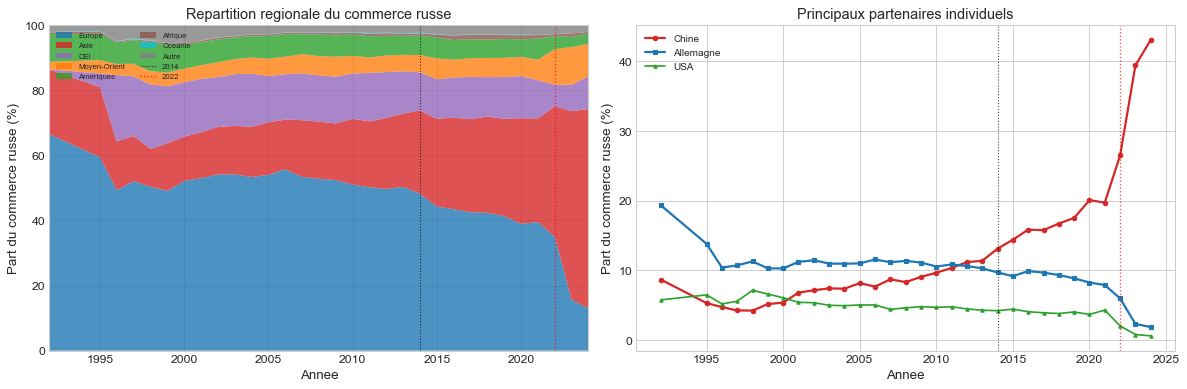

REORIENTATION — Parts regionales du commerce russe (%)
region  Europe  Asie   CEI  Moyen-Orient  Ameriques  Afrique  Oceanie  Autre
year                                                                        
1995      59.4  21.5   4.2           4.1        8.1      0.7      0.2    1.8
2000      52.1  13.6  16.7           4.1        7.5      0.5      0.1    5.4
2010      51.0  20.2  13.9           5.4        6.5      0.6      0.2    2.1
2014      48.2  25.6  11.7           5.3        6.0      0.6      0.2    2.3
2017      42.5  28.6  13.0           5.7        5.8      1.3      0.2    2.9
2021      39.5  31.8  11.7           6.3        6.4      1.1      0.1    3.0
2022      35.1  40.0   6.6          10.9        4.0      0.7      0.1    2.7
2023      15.6  57.9   8.1          11.6        3.1      1.1      0.0    2.6

--- Part de la Chine dans le commerce russe ---
  1995 : 5.3%
  2000 : 5.4%
  2010 : 9.6%
  2014 : 13.1%
  2017 : 15.8%
  2021 : 19.7%
  2022 : 26.5%
  2023 : 39.4%

HITS ALG

In [7]:
# ============================================================
# 4. REORIENTATION COMMERCIALE DE LA RUSSIE
# ============================================================
#
# Part du commerce russe par region (Europe, Asie, etc.)
# Evolution temporelle : le "pivot vers l'Est"
# ============================================================

# Calculer le commerce de la Russie par partenaire, par annee
rus_trade = atlas[atlas["country_iso3_code"] == "RUS"].copy()
rus_trade["total"] = rus_trade["export_value"] + rus_trade["import_value"]
rus_trade["region"] = rus_trade["partner_iso3_code"].map(REGIONS).fillna("Autre")

# Agreger par region et annee
by_region = (rus_trade.groupby(["year", "region"])["total"].sum()
             .unstack(fill_value=0))

# Convertir en parts (%)
shares = by_region.div(by_region.sum(axis=1), axis=0) * 100

# --- A. Stacked area chart ---
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Panel 1 : Parts en %
ax = axes[0]
region_order = ["Europe", "Asie", "CEI", "Moyen-Orient", "Ameriques", "Afrique", "Oceanie", "Autre"]
cols_present = [r for r in region_order if r in shares.columns]
colors_ordered = [REGION_COLORS.get(r, "gray") for r in cols_present]

ax.stackplot(shares.index, [shares[r] for r in cols_present],
             labels=cols_present, colors=colors_ordered, alpha=0.8)
ax.axvline(2014, color="black", ls=":", lw=1, alpha=0.7, label="2014")
ax.axvline(2022, color="red", ls=":", lw=1.2, alpha=0.7, label="2022")
ax.set_ylabel("Part du commerce russe (%)")
ax.set_xlabel("Annee")
ax.set_title("Repartition regionale du commerce russe")
ax.legend(fontsize=7, loc="upper left", ncol=2)
ax.set_xlim(shares.index.min(), shares.index.max())
ax.set_ylim(0, 100)

# Panel 2 : Focus Europe vs Chine (partenaire individuel)
ax = axes[1]
# Part de la Chine seule
chn_trade = rus_trade[rus_trade["partner_iso3_code"] == "CHN"].groupby("year")["total"].sum()
total_trade = rus_trade.groupby("year")["total"].sum()
chn_share = (chn_trade / total_trade * 100).dropna()

# Part de l'Allemagne (plus gros partenaire UE historique)
deu_trade = rus_trade[rus_trade["partner_iso3_code"] == "DEU"].groupby("year")["total"].sum()
deu_share = (deu_trade / total_trade * 100).dropna()

# Part des USA
usa_trade = rus_trade[rus_trade["partner_iso3_code"] == "USA"].groupby("year")["total"].sum()
usa_share = (usa_trade / total_trade * 100).dropna()

ax.plot(chn_share.index, chn_share.values, "o-", color="#d62728", lw=2, ms=4, label="Chine")
ax.plot(deu_share.index, deu_share.values, "s-", color="#1f77b4", lw=2, ms=4, label="Allemagne")
ax.plot(usa_share.index, usa_share.values, "^-", color="#2ca02c", lw=1.5, ms=3, label="USA")
ax.axvline(2014, color="black", ls=":", lw=1, alpha=0.7)
ax.axvline(2022, color="red", ls=":", lw=1.2, alpha=0.7)
ax.set_ylabel("Part du commerce russe (%)")
ax.set_xlabel("Annee")
ax.set_title("Principaux partenaires individuels")
ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig(FIGURES / "nb4_trade_reorientation.png", dpi=120, bbox_inches="tight")
plt.show(); plt.close("all"); gc.collect()

# --- Tableau chiffre ---
print("=" * 72)
print("REORIENTATION — Parts regionales du commerce russe (%)")
print("=" * 72)
key_years = [y for y in [1995, 2000, 2010, 2014, 2017, 2021, 2022, 2023] if y in shares.index]
if key_years:
    print(shares.loc[key_years, cols_present].round(1).to_string())

print("\n--- Part de la Chine dans le commerce russe ---")
for y in key_years:
    if y in chn_share.index:
        print(f"  {y} : {chn_share[y]:.1f}%")

# --- B. HITS Algorithm ---
print("\n" + "=" * 72)
print("HITS ALGORITHM (Hub / Authority)")
print("=" * 72)
print("  Hub = pays qui IMPORTE de beaucoup de sources (redistributeur)")
print("  Authority = pays dont les EXPORTS sont demandes partout")

for year in [FOCUS_YEARS[0], FOCUS_YEARS[-1]]:
    G = networks[year]
    hubs, authorities = nx.hits(G, max_iter=500)
    
    print(f"\n  --- {year} ---")
    print(f"  Top 5 Hubs (importateurs-redistributeurs) :")
    for iso, score in sorted(hubs.items(), key=lambda x: -x[1])[:5]:
        print(f"    {iso} : {score:.4f}")
    
    print(f"  Top 5 Authorities (exportateurs-cles) :")
    for iso, score in sorted(authorities.items(), key=lambda x: -x[1])[:5]:
        print(f"    {iso} : {score:.4f}")
    
    print(f"  Russie : Hub={hubs.get('RUS', 0):.4f}  Authority={authorities.get('RUS', 0):.4f}")
    print(f"  Chine  : Hub={hubs.get('CHN', 0):.4f}  Authority={authorities.get('CHN', 0):.4f}")


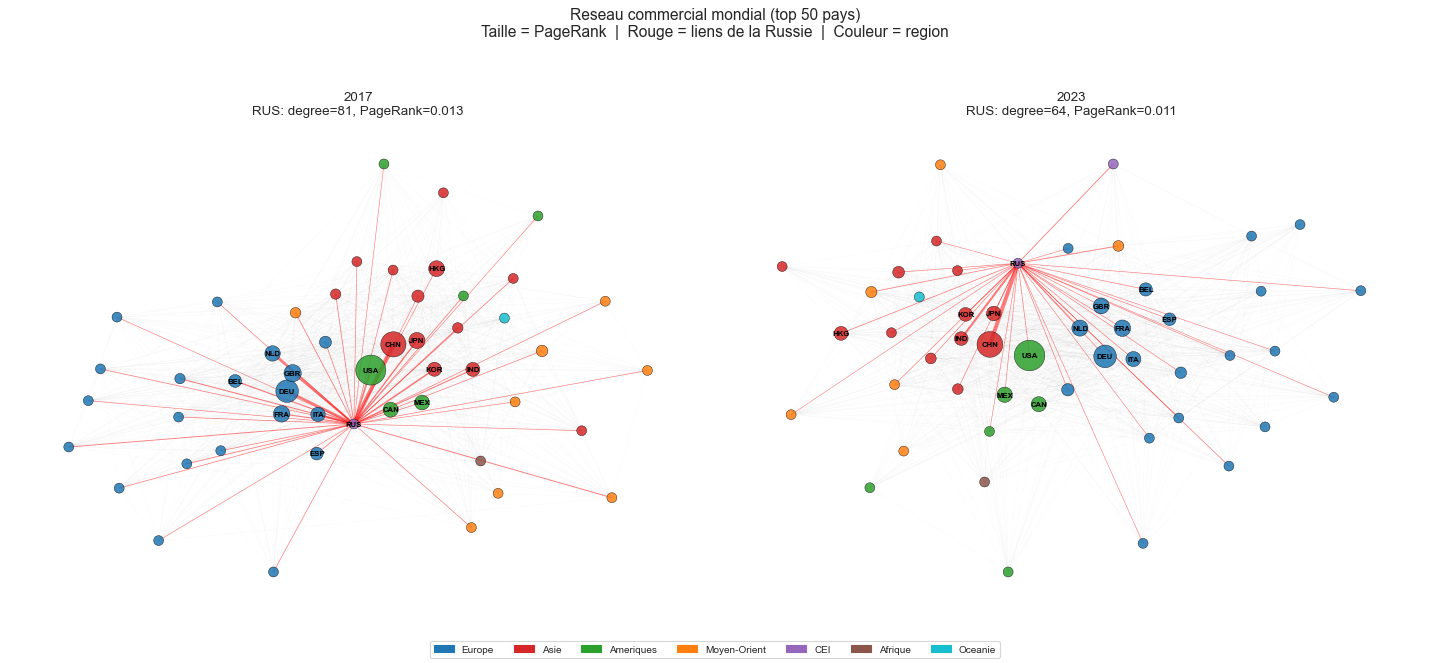

LIENS COMMERCIAUX DE LA RUSSIE — Top 10 partenaires

  2017 — Top 10 :
     1. CHN (Asie        ) :   89.5 Mrd USD
     2. DEU (Europe      ) :   54.9 Mrd USD
     3. NLD (Europe      ) :   23.6 Mrd USD
     4. ITA (Europe      ) :   23.0 Mrd USD
     5. USA (Ameriques   ) :   22.1 Mrd USD
     6. POL (Europe      ) :   20.5 Mrd USD
     7. TUR (Moyen-Orient) :   19.0 Mrd USD
     8. KOR (Asie        ) :   19.0 Mrd USD
     9. JPN (Asie        ) :   17.9 Mrd USD
    10. FRA (Europe      ) :   14.2 Mrd USD

  2023 — Top 10 :
     1. CHN (Asie        ) :  229.6 Mrd USD
     2. IND (Asie        ) :   57.7 Mrd USD
     3. TUR (Moyen-Orient) :   47.4 Mrd USD
     4. KAZ (CEI         ) :   25.5 Mrd USD
     5. DEU (Europe      ) :   13.4 Mrd USD
     6. KOR (Asie        ) :   13.2 Mrd USD
     7. BRA (Ameriques   ) :   10.3 Mrd USD
     8. ARE (Moyen-Orient) :    9.7 Mrd USD
     9. HKG (Asie        ) :    9.3 Mrd USD
    10. JPN (Asie        ) :    8.7 Mrd USD


In [8]:
# ============================================================
# 5. VISUALISATION RESEAU
# ============================================================
#
# Graphes de reseau 2017 vs 2023 colores par REGION
# avec mise en evidence des liens de la Russie
# ============================================================

compare_years = [FOCUS_YEARS[0], FOCUS_YEARS[-1]]

fig, axes = plt.subplots(1, 2, figsize=(18, 8))

for ax, year in zip(axes, compare_years):
    G = networks[year]
    G_und = G.to_undirected()
    
    # Layout stable
    pos = nx.spring_layout(G_und, weight="weight", seed=42, k=2.0, iterations=80)
    
    # PageRank pour la taille
    pr = nx.pagerank(G, weight="weight")
    
    # Couleurs par region
    node_colors = [REGION_COLORS.get(REGIONS.get(n, "Autre"), "gray") for n in G_und.nodes]
    node_sizes = [max(pr.get(n, 0.01) * 6000, 80) for n in G_und.nodes]
    
    # Aretes generales (fines, grises)
    all_edges = list(G_und.edges())
    nx.draw_networkx_edges(G_und, pos, ax=ax, edgelist=all_edges,
                           alpha=0.06, edge_color="gray", width=0.3)
    
    # Aretes de la Russie (plus epaisses, rouges)
    rus_edges = [(u, v) for u, v in G_und.edges() if u == "RUS" or v == "RUS"]
    if rus_edges:
        rus_weights = [G_und[u][v].get("weight", 1) for u, v in rus_edges]
        max_rw = max(rus_weights) if rus_weights else 1
        rus_widths = [0.5 + 3.0 * w / max_rw for w in rus_weights]
        nx.draw_networkx_edges(G_und, pos, ax=ax, edgelist=rus_edges,
                               width=rus_widths, alpha=0.5, edge_color="red")
    
    # Noeuds
    nx.draw_networkx_nodes(G_und, pos, ax=ax, node_color=node_colors,
                           node_size=node_sizes, alpha=0.85,
                           edgecolors="black", linewidths=0.4)
    
    # Labels pays importants
    top_nodes = sorted(G_und.nodes, key=lambda n: pr.get(n, 0), reverse=True)[:15]
    if "RUS" not in top_nodes:
        top_nodes.append("RUS")
    labels = {n: n for n in top_nodes if n in pos}
    nx.draw_networkx_labels(G_und, pos, labels=labels, ax=ax,
                           font_size=7, font_weight="bold")
    
    # Titre avec stats
    rus_degree = G.degree("RUS") if "RUS" in G else 0
    rus_pr_val = pr.get("RUS", 0)
    ax.set_title(f"{year}\n"
                 f"RUS: degree={rus_degree}, PageRank={rus_pr_val:.3f}",
                 fontsize=12)
    ax.axis("off")

# Legende regions
patches = [mpatches.Patch(color=c, label=r) for r, c in REGION_COLORS.items()
           if r in set(REGIONS.get(n, "Autre") for n in networks[compare_years[0]].nodes)]
fig.legend(handles=patches, loc="lower center", ncol=len(patches),
           fontsize=9, frameon=True)

fig.suptitle("Reseau commercial mondial (top 50 pays)\n"
             "Taille = PageRank  |  Rouge = liens de la Russie  |  Couleur = region",
             fontsize=14, y=1.02)
plt.tight_layout(rect=[0, 0.05, 1, 0.98])
plt.savefig(FIGURES / "nb4_network_2017_vs_2023.png", dpi=120, bbox_inches="tight")
plt.show(); plt.close("all"); gc.collect()

# --- Matrice de transition des liens russes ---
print("=" * 72)
print("LIENS COMMERCIAUX DE LA RUSSIE — Top 10 partenaires")
print("=" * 72)
for year in compare_years:
    G = networks[year]
    if "RUS" not in G:
        continue
    
    # Commerce total (in + out) avec chaque partenaire
    partners = {}
    for u, v, d in G.edges(data=True):
        if u == "RUS":
            partners[v] = partners.get(v, 0) + d["weight"]
        if v == "RUS":
            partners[u] = partners.get(u, 0) + d["weight"]
    
    sorted_p = sorted(partners.items(), key=lambda x: -x[1])[:10]
    print(f"\n  {year} — Top 10 :")
    for rank, (iso, val) in enumerate(sorted_p, 1):
        region = REGIONS.get(iso, "Autre")
        print(f"    {rank:2d}. {iso} ({region:12s}) : {val:6.1f} Mrd USD")


In [9]:
# ============================================================
# 6. Summary & conclusions
# ============================================================

print("=" * 72)
print("Summary — Network Analysis")
print("=" * 72)

print("""
RESULTATS : RUS 2017 bloc Europe, 2023 bloc Asie (incl. CHN).
  CHN part 5.3% (1995) -> 39.4% (2023). Europe 59.4% -> 15.6%.
  RUS Top partner: CHN 89.5 Bn (2017) -> 229.6 Bn (2023).
LIMITES : Atlas reconcilie. Louvain sensible aux poids.
""")

# Sauvegarder les donnees de centralite
out_path = PROCESSED / "network_centrality.csv"
cent_df.to_csv(out_path, index=False)
print(f"Centralite exportee -> {out_path}")

# Sauvegarder les parts regionales
out_path2 = PROCESSED / "russia_trade_shares_by_region.csv"
shares.to_csv(out_path2)
print(f"Parts regionales exportees -> {out_path2}")


Summary — Network Analysis

RESULTATS : RUS 2017 bloc Europe, 2023 bloc Asie (incl. CHN).
  CHN part 5.3% (1995) -> 39.4% (2023). Europe 59.4% -> 15.6%.
  RUS Top partner: CHN 89.5 Bn (2017) -> 229.6 Bn (2023).
LIMITES : Atlas reconcilie. Louvain sensible aux poids.

Centralite exportee -> d:\Users\Proprietaire\Desktop\Projet_perso\Chine-russie\russia_china_dependency\02_processed_data\network_centrality.csv
Parts regionales exportees -> d:\Users\Proprietaire\Desktop\Projet_perso\Chine-russie\russia_china_dependency\02_processed_data\russia_trade_shares_by_region.csv
